# Alternative Assets Fee Analyzer
## Modeling and Comparing Fee Structures in Hedge Funds & Private Equity

**Author:** Minas Karagiorgis  
**Purpose:** Analysis tool for understanding fee impact on alternative investment returns  
**Inspired by:** Albourne Partners' Fee & Liquidity validation work

---

### Project Overview
This notebook demonstrates:
1. **Fee Structure Modeling** - Hedge Funds (2/20) and Private Equity (2/20 with hurdle rates)
2. **Net Return Calculations** - Impact of management and performance fees on investor returns
3. **Scenario Analysis** - Comparing different fee structures and market conditions
4. **Fee Validation** - Detecting discrepancies between calculated and actual fees
5. **Visualizations** - Clear charts showing fee impact over time

---

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dataclasses import dataclass
from typing import List, Dict, Tuple

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 2. Fee Structure Classes

### Understanding Fee Structures:
- **Management Fee**: Annual fee based on AUM (typically 1-2%)
- **Performance Fee**: Fee on profits (typically 20%)
- **Hurdle Rate**: Minimum return before performance fees apply (common in PE)
- **High-Water Mark**: Performance fees only on new profits above previous peak (common in HF)
- **Clawback**: Provision to recoup excess fees if fund underperforms

In [2]:
@dataclass
class FeeStructure:
    """Base class for fee structures"""
    management_fee: float  # Annual % (e.g., 0.02 for 2%)
    performance_fee: float  # % of profits (e.g., 0.20 for 20%)
    name: str


class HedgeFundFees:
    """
    Hedge Fund Fee Calculator with High-Water Mark
    
    Typical Structure: 2/20 (2% management, 20% performance)
    - Management fee charged on NAV regardless of performance
    - Performance fee only charged on gains above high-water mark
    """
    
    def __init__(self, management_fee: float = 0.02, performance_fee: float = 0.20):
        self.management_fee = management_fee
        self.performance_fee = performance_fee
        self.high_water_mark = 0
        
    def calculate_fees(self, nav_start: float, nav_end: float) -> Dict[str, float]:
        """
        Calculate annual fees for a hedge fund
        
        Args:
            nav_start: NAV at start of period
            nav_end: NAV at end of period (before fees)
            
        Returns:
            Dictionary with management_fee, performance_fee, total_fees, net_nav
        """
        # Management fee on average NAV
        avg_nav = (nav_start + nav_end) / 2
        mgmt_fee = avg_nav * self.management_fee
        
        # Performance fee on gains above high-water mark
        nav_after_mgmt = nav_end - mgmt_fee
        
        if nav_after_mgmt > self.high_water_mark:
            profit = nav_after_mgmt - max(self.high_water_mark, nav_start)
            perf_fee = max(0, profit * self.performance_fee)
            self.high_water_mark = nav_after_mgmt - perf_fee
        else:
            perf_fee = 0
        
        total_fees = mgmt_fee + perf_fee
        net_nav = nav_end - total_fees
        
        return {
            'management_fee': mgmt_fee,
            'performance_fee': perf_fee,
            'total_fees': total_fees,
            'net_nav': net_nav,
            'high_water_mark': self.high_water_mark
        }
    
    def reset_high_water_mark(self):
        """Reset high-water mark (e.g., for new fund or analysis)"""
        self.high_water_mark = 0


class PrivateEquityFees:
    """
    Private Equity Fee Calculator with Hurdle Rate and Catch-up
    
    Typical Structure: 2/20 with 8% hurdle
    - Management fee on committed capital (during investment period) or invested capital
    - Carried interest (20%) only after investors achieve hurdle rate (typically 8%)
    - Catch-up provision: GP gets larger % to "catch up" after hurdle met
    """
    
    def __init__(self, 
                 management_fee: float = 0.02,
                 carried_interest: float = 0.20,
                 hurdle_rate: float = 0.08,
                 catch_up: float = 1.0):
        """
        Args:
            management_fee: Annual fee as % of committed/invested capital
            carried_interest: GP's share of profits above hurdle ("carry")
            hurdle_rate: Minimum IRR before carry applies (preferred return)
            catch_up: % of profits GP receives after hurdle until they reach their full carry
        """
        self.management_fee = management_fee
        self.carried_interest = carried_interest
        self.hurdle_rate = hurdle_rate
        self.catch_up = catch_up
        
    def calculate_fees(self, 
                      committed_capital: float,
                      invested_capital: float,
                      final_value: float,
                      years: int,
                      investment_period: bool = True) -> Dict[str, float]:
        """
        Calculate fees for a PE fund
        
        Args:
            committed_capital: Total capital committed by LPs
            invested_capital: Capital actually deployed
            final_value: Exit value of investments
            years: Fund life in years
            investment_period: If True, charge on committed capital; else on invested
        """
        # Management fees over fund life
        base_for_mgmt = committed_capital if investment_period else invested_capital
        annual_mgmt_fee = base_for_mgmt * self.management_fee
        total_mgmt_fees = annual_mgmt_fee * years
        
        # Calculate hurdle amount (what LPs must get before GP gets carry)
        hurdle_value = invested_capital * ((1 + self.hurdle_rate) ** years)
        
        # Distribute proceeds
        value_after_mgmt = final_value - total_mgmt_fees
        
        if value_after_mgmt <= hurdle_value:
            # Below hurdle: LPs get everything after management fees
            carry = 0
            lp_proceeds = value_after_mgmt
        else:
            # Above hurdle: GP gets carry on profits above hurdle
            profit_above_hurdle = value_after_mgmt - hurdle_value
            
            # Apply catch-up (GP gets higher % initially to "catch up")
            catch_up_amount = min(profit_above_hurdle, 
                                 hurdle_value * self.carried_interest / (1 - self.carried_interest))
            gp_catch_up = catch_up_amount * self.catch_up
            
            # Remaining profits split by carry %
            remaining_profit = profit_above_hurdle - catch_up_amount
            gp_remaining = remaining_profit * self.carried_interest
            
            carry = gp_catch_up + gp_remaining
            lp_proceeds = value_after_mgmt - carry
        
        total_fees = total_mgmt_fees + carry
        
        # Calculate realized IRR for LPs
        lp_multiple = lp_proceeds / invested_capital
        lp_irr = (lp_multiple ** (1/years)) - 1 if years > 0 else 0
        
        return {
            'management_fees': total_mgmt_fees,
            'carried_interest': carry,
            'total_fees': total_fees,
            'lp_proceeds': lp_proceeds,
            'lp_irr': lp_irr,
            'hurdle_met': value_after_mgmt > hurdle_value,
            'gross_multiple': final_value / invested_capital,
            'net_multiple': lp_proceeds / invested_capital
        }

print("✓ Fee structure classes defined")

✓ Fee structure classes defined


## 3. Scenario Simulation Engine

In [3]:
def simulate_hedge_fund_returns(initial_nav: float,
                               annual_return: float,
                               volatility: float,
                               years: int,
                               management_fee: float = 0.02,
                               performance_fee: float = 0.20,
                               seed: int = 42) -> pd.DataFrame:
    """
    Simulate hedge fund performance over time with fees
    
    Args:
        initial_nav: Starting NAV
        annual_return: Expected annual return (e.g., 0.10 for 10%)
        volatility: Annual volatility (e.g., 0.15 for 15%)
        years: Number of years to simulate
        management_fee: Annual management fee
        performance_fee: Performance fee on profits
        seed: Random seed for reproducibility
    """
    np.random.seed(seed)
    
    hf_fees = HedgeFundFees(management_fee, performance_fee)
    
    results = []
    nav_gross = initial_nav
    nav_net = initial_nav
    
    for year in range(years + 1):
        if year == 0:
            results.append({
                'year': year,
                'nav_gross': nav_gross,
                'nav_net': nav_net,
                'management_fee': 0,
                'performance_fee': 0,
                'total_fees': 0,
                'cumulative_fees': 0
            })
            continue
        
        # Generate random return
        random_return = np.random.normal(annual_return, volatility)
        
        # Gross NAV (without fees)
        nav_gross_start = nav_gross
        nav_gross = nav_gross * (1 + random_return)
        
        # Calculate fees on net NAV
        fee_calc = hf_fees.calculate_fees(results[-1]['nav_net'], 
                                         nav_gross * (results[-1]['nav_net'] / nav_gross_start))
        
        nav_net = fee_calc['net_nav']
        
        cumulative_fees = results[-1]['cumulative_fees'] + fee_calc['total_fees']
        
        results.append({
            'year': year,
            'nav_gross': nav_gross,
            'nav_net': nav_net,
            'management_fee': fee_calc['management_fee'],
            'performance_fee': fee_calc['performance_fee'],
            'total_fees': fee_calc['total_fees'],
            'cumulative_fees': cumulative_fees
        })
    
    df = pd.DataFrame(results)
    df['fee_drag'] = ((df['nav_gross'] - df['nav_net']) / df['nav_gross'] * 100)
    
    return df

print("✓ Simulation engine ready")

✓ Simulation engine ready


## 4. Example 1: Hedge Fund Analysis

### Scenario: Compare traditional 2/20 vs. investor-friendly 1/15 structure

In [4]:
# Simulation parameters
INITIAL_INVESTMENT = 10_000_000  # $10M
EXPECTED_RETURN = 0.12  # 12% annually
VOLATILITY = 0.18  # 18% volatility
YEARS = 10

# Simulate two fee structures
traditional_2_20 = simulate_hedge_fund_returns(
    INITIAL_INVESTMENT, EXPECTED_RETURN, VOLATILITY, YEARS,
    management_fee=0.02, performance_fee=0.20, seed=42
)

investor_friendly_1_15 = simulate_hedge_fund_returns(
    INITIAL_INVESTMENT, EXPECTED_RETURN, VOLATILITY, YEARS,
    management_fee=0.015, performance_fee=0.15, seed=42
)

# Summary statistics
print("\n" + "="*60)
print("HEDGE FUND FEE COMPARISON - 10 YEAR HORIZON")
print("="*60)
print(f"\nInitial Investment: ${INITIAL_INVESTMENT:,.0f}")
print(f"Gross Final Value: ${traditional_2_20.iloc[-1]['nav_gross']:,.0f}")
print(f"Gross Return: {(traditional_2_20.iloc[-1]['nav_gross']/INITIAL_INVESTMENT - 1)*100:.1f}%\n")

print("\n2/20 Structure (Traditional):")
print(f"  Final Net Value: ${traditional_2_20.iloc[-1]['nav_net']:,.0f}")
print(f"  Total Fees Paid: ${traditional_2_20.iloc[-1]['cumulative_fees']:,.0f}")
print(f"  Net Return: {(traditional_2_20.iloc[-1]['nav_net']/INITIAL_INVESTMENT - 1)*100:.1f}%")
print(f"  Fee Drag: {traditional_2_20.iloc[-1]['fee_drag']:.1f}%")

print("\n1.5/15 Structure (Investor-Friendly):")
print(f"  Final Net Value: ${investor_friendly_1_15.iloc[-1]['nav_net']:,.0f}")
print(f"  Total Fees Paid: ${investor_friendly_1_15.iloc[-1]['cumulative_fees']:,.0f}")
print(f"  Net Return: {(investor_friendly_1_15.iloc[-1]['nav_net']/INITIAL_INVESTMENT - 1)*100:.1f}%")
print(f"  Fee Drag: {investor_friendly_1_15.iloc[-1]['fee_drag']:.1f}%")

fee_savings = traditional_2_20.iloc[-1]['cumulative_fees'] - investor_friendly_1_15.iloc[-1]['cumulative_fees']
print(f"\n💰 Fee Savings with 1.5/15: ${fee_savings:,.0f}")
print(f"   ({fee_savings/traditional_2_20.iloc[-1]['cumulative_fees']*100:.1f}% reduction)")
print("="*60)


HEDGE FUND FEE COMPARISON - 10 YEAR HORIZON

Initial Investment: $10,000,000
Gross Final Value: $59,092,547
Gross Return: 490.9%


2/20 Structure (Traditional):
  Final Net Value: $36,682,204
  Total Fees Paid: $10,955,652
  Net Return: 266.8%
  Fee Drag: 37.9%

1.5/15 Structure (Investor-Friendly):
  Final Net Value: $41,131,233
  Total Fees Paid: $8,924,075
  Net Return: 311.3%
  Fee Drag: 30.4%

💰 Fee Savings with 1.5/15: $2,031,577
   (18.5% reduction)


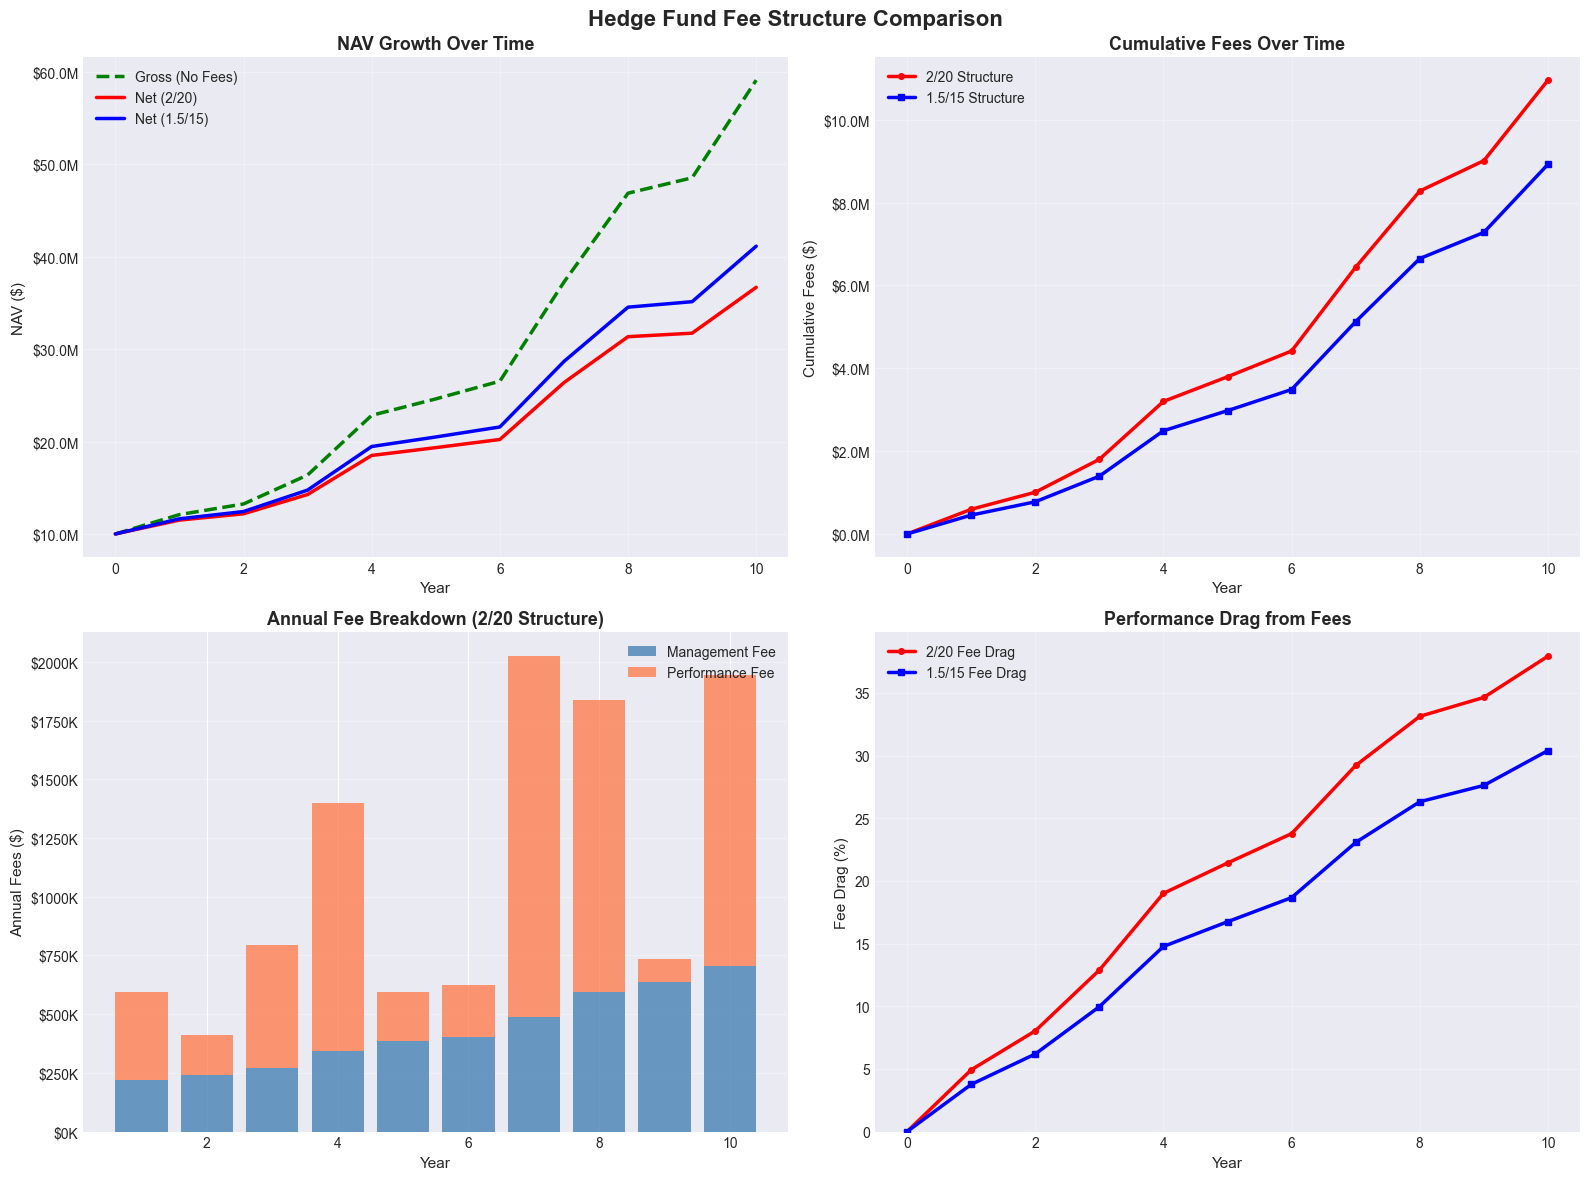

In [5]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hedge Fund Fee Structure Comparison', fontsize=16, fontweight='bold')

# Plot 1: NAV Growth Over Time
ax1 = axes[0, 0]
ax1.plot(traditional_2_20['year'], traditional_2_20['nav_gross'], 
         label='Gross (No Fees)', linewidth=2.5, linestyle='--', color='green')
ax1.plot(traditional_2_20['year'], traditional_2_20['nav_net'], 
         label='Net (2/20)', linewidth=2.5, color='red')
ax1.plot(investor_friendly_1_15['year'], investor_friendly_1_15['nav_net'], 
         label='Net (1.5/15)', linewidth=2.5, color='blue')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('NAV ($)', fontsize=11)
ax1.set_title('NAV Growth Over Time', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Plot 2: Cumulative Fees
ax2 = axes[0, 1]
ax2.plot(traditional_2_20['year'], traditional_2_20['cumulative_fees'], 
         label='2/20 Structure', linewidth=2.5, color='red', marker='o', markersize=4)
ax2.plot(investor_friendly_1_15['year'], investor_friendly_1_15['cumulative_fees'], 
         label='1.5/15 Structure', linewidth=2.5, color='blue', marker='s', markersize=4)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Cumulative Fees ($)', fontsize=11)
ax2.set_title('Cumulative Fees Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Plot 3: Annual Fee Breakdown (2/20)
ax3 = axes[1, 0]
years = traditional_2_20['year'][1:]
mgmt_fees = traditional_2_20['management_fee'][1:]
perf_fees = traditional_2_20['performance_fee'][1:]

ax3.bar(years, mgmt_fees, label='Management Fee', alpha=0.8, color='steelblue')
ax3.bar(years, perf_fees, bottom=mgmt_fees, label='Performance Fee', alpha=0.8, color='coral')
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Annual Fees ($)', fontsize=11)
ax3.set_title('Annual Fee Breakdown (2/20 Structure)', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

# Plot 4: Fee Drag Comparison
ax4 = axes[1, 1]
ax4.plot(traditional_2_20['year'], traditional_2_20['fee_drag'], 
         label='2/20 Fee Drag', linewidth=2.5, color='red', marker='o', markersize=4)
ax4.plot(investor_friendly_1_15['year'], investor_friendly_1_15['fee_drag'], 
         label='1.5/15 Fee Drag', linewidth=2.5, color='blue', marker='s', markersize=4)
ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Fee Drag (%)', fontsize=11)
ax4.set_title('Performance Drag from Fees', fontsize=13, fontweight='bold')
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 5. Example 2: Private Equity Analysis

### Scenario: PE Fund with varying exit multiples

In [6]:
# PE Fund parameters
COMMITTED_CAPITAL = 100_000_000  # $100M fund
INVESTED_CAPITAL = 80_000_000    # 80% deployed
FUND_LIFE = 10  # years

# Test different exit scenarios
exit_multiples = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
pe_results = []

pe_fund = PrivateEquityFees(
    management_fee=0.02,
    carried_interest=0.20,
    hurdle_rate=0.08
)

print("\n" + "="*80)
print("PRIVATE EQUITY FEE ANALYSIS - 10 YEAR FUND")
print("="*80)
print(f"Committed Capital: ${COMMITTED_CAPITAL/1e6:.0f}M")
print(f"Invested Capital: ${INVESTED_CAPITAL/1e6:.0f}M")
print(f"Fee Structure: 2% management + 20% carry with 8% hurdle\n")
print("="*80)
print(f"{'Exit':<10} {'Gross':<12} {'Net':<12} {'Mgmt':<12} {'Carry':<12} {'LP IRR':<10} {'Hurdle'}")
print(f"{'Multiple':<10} {'Multiple':<12} {'Multiple':<12} {'Fees':<12} {'(20%)':<12} {'Net':<10} {'Met?'}")
print("="*80)

for multiple in exit_multiples:
    final_value = INVESTED_CAPITAL * multiple
    
    results = pe_fund.calculate_fees(
        COMMITTED_CAPITAL,
        INVESTED_CAPITAL,
        final_value,
        FUND_LIFE
    )
    
    pe_results.append({
        'exit_multiple': multiple,
        **results
    })
    
    hurdle_status = "✓ Yes" if results['hurdle_met'] else "✗ No"
    
    print(f"{multiple:<10.1f} "
          f"{results['gross_multiple']:<12.2f} "
          f"{results['net_multiple']:<12.2f} "
          f"${results['management_fees']/1e6:<11.1f}M "
          f"${results['carried_interest']/1e6:<11.1f}M "
          f"{results['lp_irr']*100:<9.1f}% "
          f"{hurdle_status}")

print("="*80)

pe_df = pd.DataFrame(pe_results)


PRIVATE EQUITY FEE ANALYSIS - 10 YEAR FUND
Committed Capital: $100M
Invested Capital: $80M
Fee Structure: 2% management + 20% carry with 8% hurdle

Exit       Gross        Net          Mgmt         Carry        LP IRR     Hurdle
Multiple   Multiple     Multiple     Fees         (20%)        Net        Met?
1.5        1.50         1.25         $20.0       M $0.0        M 2.3      % ✗ No
2.0        2.00         1.75         $20.0       M $0.0        M 5.8      % ✗ No
2.5        2.50         2.16         $20.0       M $7.3        M 8.0      % ✓ Yes
3.0        3.00         2.20         $20.0       M $44.0       M 8.2      % ✓ Yes
3.5        3.50         2.60         $20.0       M $52.0       M 10.0     % ✓ Yes
4.0        4.00         3.00         $20.0       M $60.0       M 11.6     % ✓ Yes


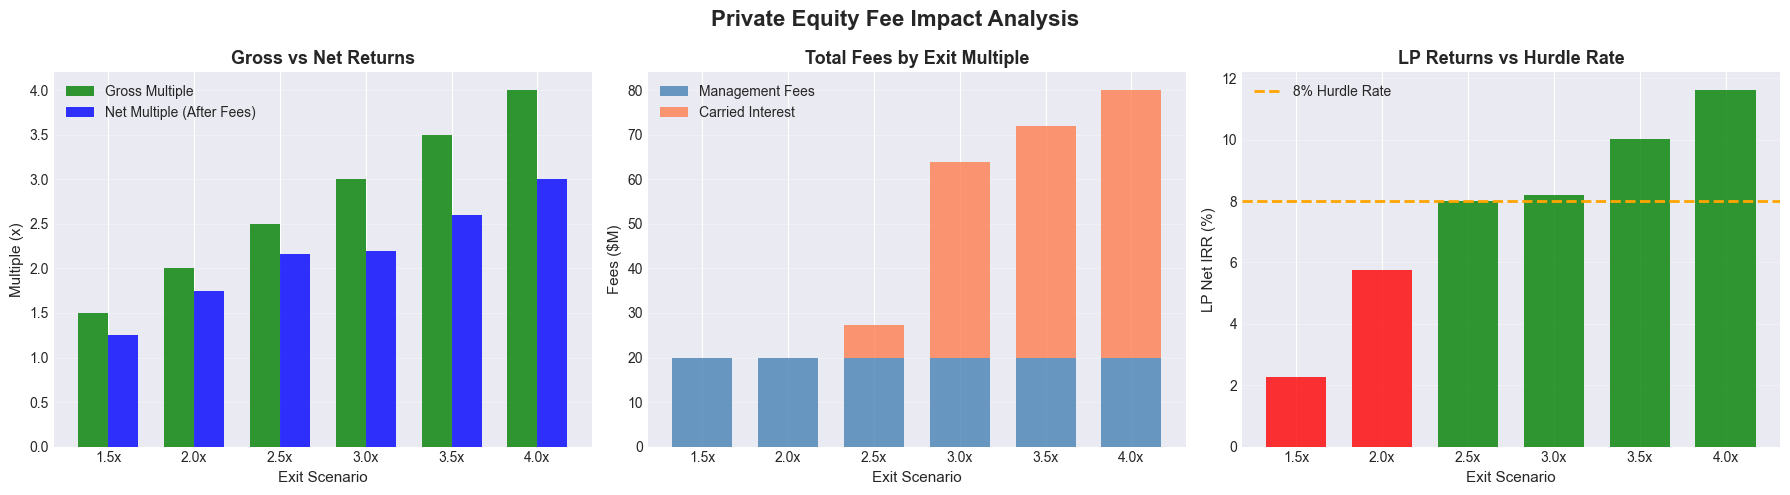

In [7]:
# PE Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Private Equity Fee Impact Analysis', fontsize=16, fontweight='bold')

# Plot 1: Gross vs Net Multiple
ax1 = axes[0]
x_pos = np.arange(len(pe_df))
width = 0.35

ax1.bar(x_pos - width/2, pe_df['gross_multiple'], width, 
        label='Gross Multiple', alpha=0.8, color='green')
ax1.bar(x_pos + width/2, pe_df['net_multiple'], width, 
        label='Net Multiple (After Fees)', alpha=0.8, color='blue')
ax1.set_xlabel('Exit Scenario', fontsize=11)
ax1.set_ylabel('Multiple (x)', fontsize=11)
ax1.set_title('Gross vs Net Returns', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f"{m:.1f}x" for m in pe_df['exit_multiple']])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Fee Breakdown
ax2 = axes[1]
ax2.bar(x_pos, pe_df['management_fees']/1e6, width*2, 
        label='Management Fees', alpha=0.8, color='steelblue')
ax2.bar(x_pos, pe_df['carried_interest']/1e6, width*2, 
        bottom=pe_df['management_fees']/1e6,
        label='Carried Interest', alpha=0.8, color='coral')
ax2.set_xlabel('Exit Scenario', fontsize=11)
ax2.set_ylabel('Fees ($M)', fontsize=11)
ax2.set_title('Total Fees by Exit Multiple', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{m:.1f}x" for m in pe_df['exit_multiple']])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: LP IRR
ax3 = axes[2]
colors = ['red' if not hurdle else 'green' for hurdle in pe_df['hurdle_met']]
ax3.bar(x_pos, pe_df['lp_irr']*100, width*2, alpha=0.8, color=colors)
ax3.axhline(y=8, color='orange', linestyle='--', linewidth=2, label='8% Hurdle Rate')
ax3.set_xlabel('Exit Scenario', fontsize=11)
ax3.set_ylabel('LP Net IRR (%)', fontsize=11)
ax3.set_title('LP Returns vs Hurdle Rate', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f"{m:.1f}x" for m in pe_df['exit_multiple']])
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Fee Validation Tool

### Simulating Albourne's Fee Reconciliation Process

In [8]:
class FeeValidator:
    """
    Fee Validation Tool - Similar to Albourne's FeeMometer™
    
    Compares calculated fees vs. reported fees to identify discrepancies
    """
    
    def __init__(self, tolerance: float = 0.01):
        """
        Args:
            tolerance: Acceptable variance (e.g., 0.01 = 1% tolerance)
        """
        self.tolerance = tolerance
        self.validations = []
    
    def validate_hedge_fund_fees(self,
                                fund_name: str,
                                reported_mgmt_fee: float,
                                reported_perf_fee: float,
                                nav_start: float,
                                nav_end: float,
                                mgmt_fee_rate: float = 0.02,
                                perf_fee_rate: float = 0.20) -> Dict:
        """
        Validate reported fees against calculated fees
        """
        hf = HedgeFundFees(mgmt_fee_rate, perf_fee_rate)
        hf.high_water_mark = nav_start  # Simplified assumption
        
        calculated = hf.calculate_fees(nav_start, nav_end)
        
        mgmt_diff = abs(calculated['management_fee'] - reported_mgmt_fee)
        perf_diff = abs(calculated['performance_fee'] - reported_perf_fee)
        
        mgmt_variance = mgmt_diff / calculated['management_fee'] if calculated['management_fee'] > 0 else 0
        perf_variance = perf_diff / calculated['performance_fee'] if calculated['performance_fee'] > 0 else 0
        
        mgmt_status = "✓ PASS" if mgmt_variance <= self.tolerance else "✗ FAIL"
        perf_status = "✓ PASS" if perf_variance <= self.tolerance else "✗ FAIL"
        
        validation = {
            'fund_name': fund_name,
            'reported_mgmt_fee': reported_mgmt_fee,
            'calculated_mgmt_fee': calculated['management_fee'],
            'mgmt_difference': mgmt_diff,
            'mgmt_variance_%': mgmt_variance * 100,
            'mgmt_status': mgmt_status,
            'reported_perf_fee': reported_perf_fee,
            'calculated_perf_fee': calculated['performance_fee'],
            'perf_difference': perf_diff,
            'perf_variance_%': perf_variance * 100,
            'perf_status': perf_status
        }
        
        self.validations.append(validation)
        return validation
    
    def generate_report(self) -> pd.DataFrame:
        """Generate validation report"""
        return pd.DataFrame(self.validations)


# Example: Validate fees for multiple funds
validator = FeeValidator(tolerance=0.02)  # 2% tolerance

# Simulated fund data
funds_to_validate = [
    {'name': 'Alpha Hedge Fund', 'nav_start': 10_000_000, 'nav_end': 11_500_000, 
     'reported_mgmt': 207_500, 'reported_perf': 300_000},
    {'name': 'Beta Long/Short', 'nav_start': 25_000_000, 'nav_end': 26_200_000,
     'reported_mgmt': 512_000, 'reported_perf': 240_000},
    {'name': 'Gamma Macro Fund', 'nav_start': 50_000_000, 'nav_end': 48_500_000,
     'reported_mgmt': 985_000, 'reported_perf': 0},
]

print("\n" + "="*100)
print("FEE VALIDATION REPORT - Hedge Fund Fee Reconciliation")
print("="*100 + "\n")

for fund in funds_to_validate:
    result = validator.validate_hedge_fund_fees(
        fund['name'],
        fund['reported_mgmt'],
        fund['reported_perf'],
        fund['nav_start'],
        fund['nav_end']
    )
    
    print(f"Fund: {result['fund_name']}")
    print(f"  Management Fee:   Reported: ${result['reported_mgmt_fee']:>12,.0f} | "
          f"Calculated: ${result['calculated_mgmt_fee']:>12,.0f} | "
          f"Variance: {result['mgmt_variance_%']:>6.2f}% | {result['mgmt_status']}")
    print(f"  Performance Fee:  Reported: ${result['reported_perf_fee']:>12,.0f} | "
          f"Calculated: ${result['calculated_perf_fee']:>12,.0f} | "
          f"Variance: {result['perf_variance_%']:>6.2f}% | {result['perf_status']}")
    print()

validation_df = validator.generate_report()
print("="*100)
print(f"\nSummary: {len(validation_df)} funds validated")
passed = len(validation_df[(validation_df['mgmt_status'] == '✓ PASS') & 
                           (validation_df['perf_status'] == '✓ PASS')])
print(f"Passed: {passed}/{len(validation_df)} ({passed/len(validation_df)*100:.0f}%)")
print("="*100)


FEE VALIDATION REPORT - Hedge Fund Fee Reconciliation

Fund: Alpha Hedge Fund
  Management Fee:   Reported: $     207,500 | Calculated: $     215,000 | Variance:   3.49% | ✗ FAIL
  Performance Fee:  Reported: $     300,000 | Calculated: $     257,000 | Variance:  16.73% | ✗ FAIL

Fund: Beta Long/Short
  Management Fee:   Reported: $     512,000 | Calculated: $     512,000 | Variance:   0.00% | ✓ PASS
  Performance Fee:  Reported: $     240,000 | Calculated: $     137,600 | Variance:  74.42% | ✗ FAIL

Fund: Gamma Macro Fund
  Management Fee:   Reported: $     985,000 | Calculated: $     985,000 | Variance:   0.00% | ✓ PASS
  Performance Fee:  Reported: $           0 | Calculated: $           0 | Variance:   0.00% | ✓ PASS


Summary: 3 funds validated
Passed: 1/3 (33%)


## 7. Interactive Fee Calculator

In [9]:
def interactive_fee_calculator():
    """
    Interactive calculator for quick fee estimates
    """
    print("\n" + "="*60)
    print("INTERACTIVE FEE CALCULATOR")
    print("="*60)
    
    fund_type = input("\nFund Type (HF for Hedge Fund, PE for Private Equity): ").strip().upper()
    
    if fund_type == 'HF':
        print("\n--- Hedge Fund Fee Calculator ---")
        nav_start = float(input("Starting NAV ($): "))
        nav_end = float(input("Ending NAV (before fees) ($): "))
        mgmt_rate = float(input("Management Fee % (e.g., 2 for 2%): ")) / 100
        perf_rate = float(input("Performance Fee % (e.g., 20 for 20%): ")) / 100
        
        hf = HedgeFundFees(mgmt_rate, perf_rate)
        hf.high_water_mark = nav_start
        result = hf.calculate_fees(nav_start, nav_end)
        
        print("\n" + "-"*60)
        print("RESULTS:")
        print(f"  Management Fee:    ${result['management_fee']:>15,.2f}")
        print(f"  Performance Fee:   ${result['performance_fee']:>15,.2f}")
        print(f"  Total Fees:        ${result['total_fees']:>15,.2f}")
        print(f"  Net NAV:           ${result['net_nav']:>15,.2f}")
        print(f"  Return (Gross):    {((nav_end/nav_start - 1)*100):>14.2f}%")
        print(f"  Return (Net):      {((result['net_nav']/nav_start - 1)*100):>14.2f}%")
        print("-"*60)
        
    elif fund_type == 'PE':
        print("\n--- Private Equity Fee Calculator ---")
        committed = float(input("Committed Capital ($): "))
        invested = float(input("Invested Capital ($): "))
        final_value = float(input("Final Portfolio Value ($): "))
        years = int(input("Fund Life (years): "))
        mgmt_rate = float(input("Management Fee % (e.g., 2 for 2%): ")) / 100
        carry = float(input("Carried Interest % (e.g., 20 for 20%): ")) / 100
        hurdle = float(input("Hurdle Rate % (e.g., 8 for 8%): ")) / 100
        
        pe = PrivateEquityFees(mgmt_rate, carry, hurdle)
        result = pe.calculate_fees(committed, invested, final_value, years)
        
        print("\n" + "-"*60)
        print("RESULTS:")
        print(f"  Management Fees:   ${result['management_fees']:>15,.2f}")
        print(f"  Carried Interest:  ${result['carried_interest']:>15,.2f}")
        print(f"  Total Fees:        ${result['total_fees']:>15,.2f}")
        print(f"  LP Proceeds:       ${result['lp_proceeds']:>15,.2f}")
        print(f"  Gross Multiple:    {result['gross_multiple']:>15.2f}x")
        print(f"  Net Multiple:      {result['net_multiple']:>15.2f}x")
        print(f"  LP IRR (Net):      {result['lp_irr']*100:>14.2f}%")
        print(f"  Hurdle Met:        {'Yes ✓' if result['hurdle_met'] else 'No ✗':>15}")
        print("-"*60)
    else:
        print("Invalid fund type. Please enter 'HF' or 'PE'.")

# Uncomment to run interactively:
# interactive_fee_calculator()

## 8. Key Insights & Conclusions

### What This Analysis Shows:

1. **Fee Impact is Substantial**
   - Over 10 years, a 2/20 structure can consume 15-25% of gross returns
   - Even small fee reductions (2/20 → 1.5/15) can save millions for large portfolios

2. **Structure Matters**
   - High-water marks protect investors from paying performance fees on recovered losses
   - Hurdle rates ensure GPs only earn carry after investors achieve minimum returns
   - Catch-up provisions affect how quickly GPs reach their full carry allocation

3. **Validation is Critical**
   - Fee calculation errors are common in complex structures
   - Automated validation (like Albourne's FeeConciliation™) can identify discrepancies
   - Small percentage errors compound significantly over time

4. **Transparency Drives Better Outcomes**
   - Clear fee modeling helps investors negotiate better terms
   - Understanding fee mechanics enables better fund selection
   - Regular validation protects investor capital

---

### Relevance to Albourne's Fee & Liquidity Team:

This project demonstrates:
- ✓ Understanding of alternative asset fee structures
- ✓ Quantitative modeling skills (Python, data analysis)
- ✓ Ability to validate and reconcile complex calculations
- ✓ Data visualization for stakeholder communication
- ✓ Attention to detail in financial calculations

---

### Next Steps & Extensions:

1. Add more complex fee structures (1 or 30, beta hurdles)
2. Incorporate clawback provision modeling
3. Build waterfall distribution models for PE
4. Add Monte Carlo simulation for probabilistic outcomes
5. Create portfolio-level fee aggregation tools
6. Develop API integration for live data feeds

---

## 9. Export Results

In [10]:
# Export data to CSV for further analysis
traditional_2_20.to_csv('hedge_fund_2_20_simulation.csv', index=False)
investor_friendly_1_15.to_csv('hedge_fund_1_15_simulation.csv', index=False)
pe_df.to_csv('private_equity_scenarios.csv', index=False)
validation_df.to_csv('fee_validation_report.csv', index=False)

print("✓ Data exported to CSV files")
print("  - hedge_fund_2_20_simulation.csv")
print("  - hedge_fund_1_15_simulation.csv")
print("  - private_equity_scenarios.csv")
print("  - fee_validation_report.csv")

✓ Data exported to CSV files
  - hedge_fund_2_20_simulation.csv
  - hedge_fund_1_15_simulation.csv
  - private_equity_scenarios.csv
  - fee_validation_report.csv


---

## About This Project

**Created by:** Minas Karagiorgis  
**Contact:** minaskaragiorgi28@gmail.com  
**GitHub:** [Link to repository]  

**Motivation:** This project was developed to demonstrate practical understanding of alternative asset fee structures, inspired by the work done at Albourne Partners' Fee & Liquidity team. As a Computer Science student with interest in finance and quantitative analysis, this tool showcases the intersection of programming skills and financial modeling.

**Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

**Acknowledgments:** Fee structure information based on industry standards and publicly available documentation from Albourne Partners and other alternative investment sources.

---